# 🌿 Plant Disease Detection — Complete Notebook

**Dataset:** PlantVillage (Kaggle)

**Sections:**
1. Installations & Imports
2. Config & Paths
3. EDA
4. Data Split (70/15/15)
5. Feature Extraction (Color Histogram + LBP + GLCM)
6. Classical ML — KNN / Naive Bayes
7. Bagging / AdaBoost / GridSearch
8. CNN from Scratch (PyTorch — VGG-style)
9. Autoencoder (Keras/TensorFlow)
10. Transfer Learning — MobileNetV2 & EfficientNetB0
11. Optimizer Comparison (Adam / SGD / RMSprop)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Installations

In [2]:
!pip install tqdm
!pip install -U scikit-image
!pip install split-folders
!pip install tensorflow
!pip install torch torchvision
!pip install torchinfo torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 42.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.8 MB/s eta 0:00:00


## 2. Imports

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from PIL import Image
import random
import cv2
import splitfolders
import pandas as pd
import numpy as np
import tensorflow as tf
from skimage.feature import local_binary_pattern
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import preprocess_input
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchinfo
from torchinfo import summary
from torchmetrics import Accuracy
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

## 3. Config & Paths

In [ ]:
# ── Paths (Kaggle) ────────────────────────────────────────────
IMAGES_FOLDERS_PATH = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
OUTPUT_FOLDER       = "/kaggle/working/plantdisease_split"

# ── Image settings ────────────────────────────────────────────
WIDTH    = 224
HEIGHT   = 224
CHANNELS = 3

# ── LBP settings ──────────────────────────────────────────────
LBP_RADIUS   = 3
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD   = 'uniform'

# ── PyTorch device ────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
IMAGES_FOLDERS_PATH = "/content/drive/MyDrive/plantdisease/PlantVillage"
OUTPUT_FOLDER = 'plantdisease_split'
WIDTH = 224
HEIGHT = 224
CHANNELS = 3
LBP_RADIUS = 3
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD = 'uniform'

## 4. EDA — Exploratory Data Analysis

Image distribution across classes:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                        Tomato_Early_blight   1000
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


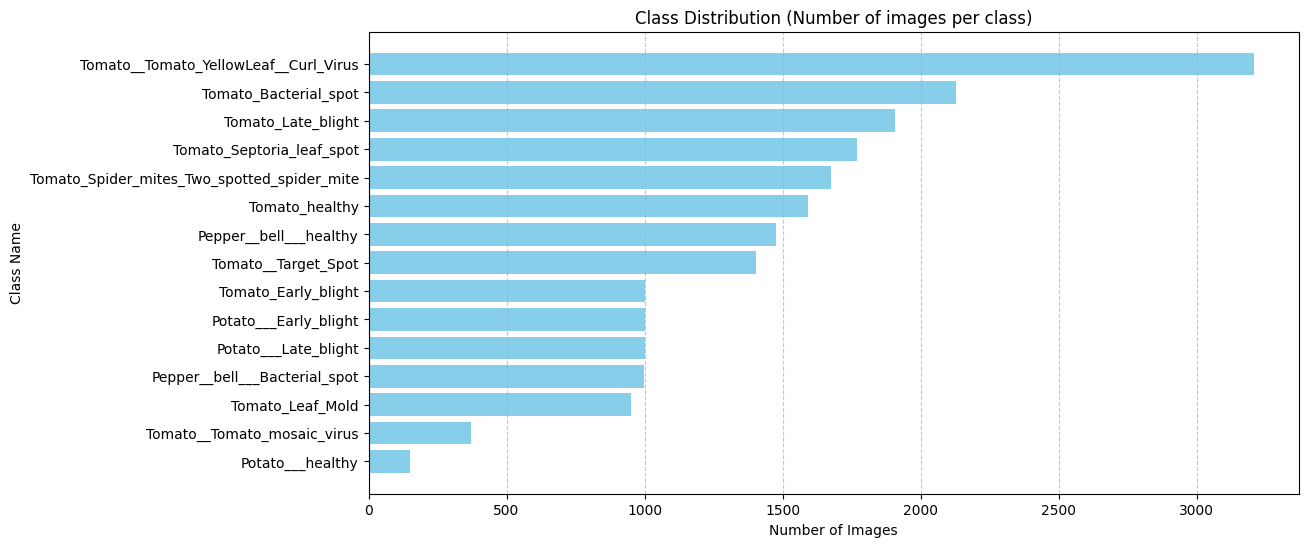

In [ ]:
data = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data.append({'Class': class_name, 'Count': count})

df_dist = pd.DataFrame(data).sort_values(by='Count', ascending=False)

print("Image distribution across classes:")
print(df_dist.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(df_dist['Class'], df_dist['Count'], color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.title('Class Distribution (Number of images per class)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Classes Number: 15


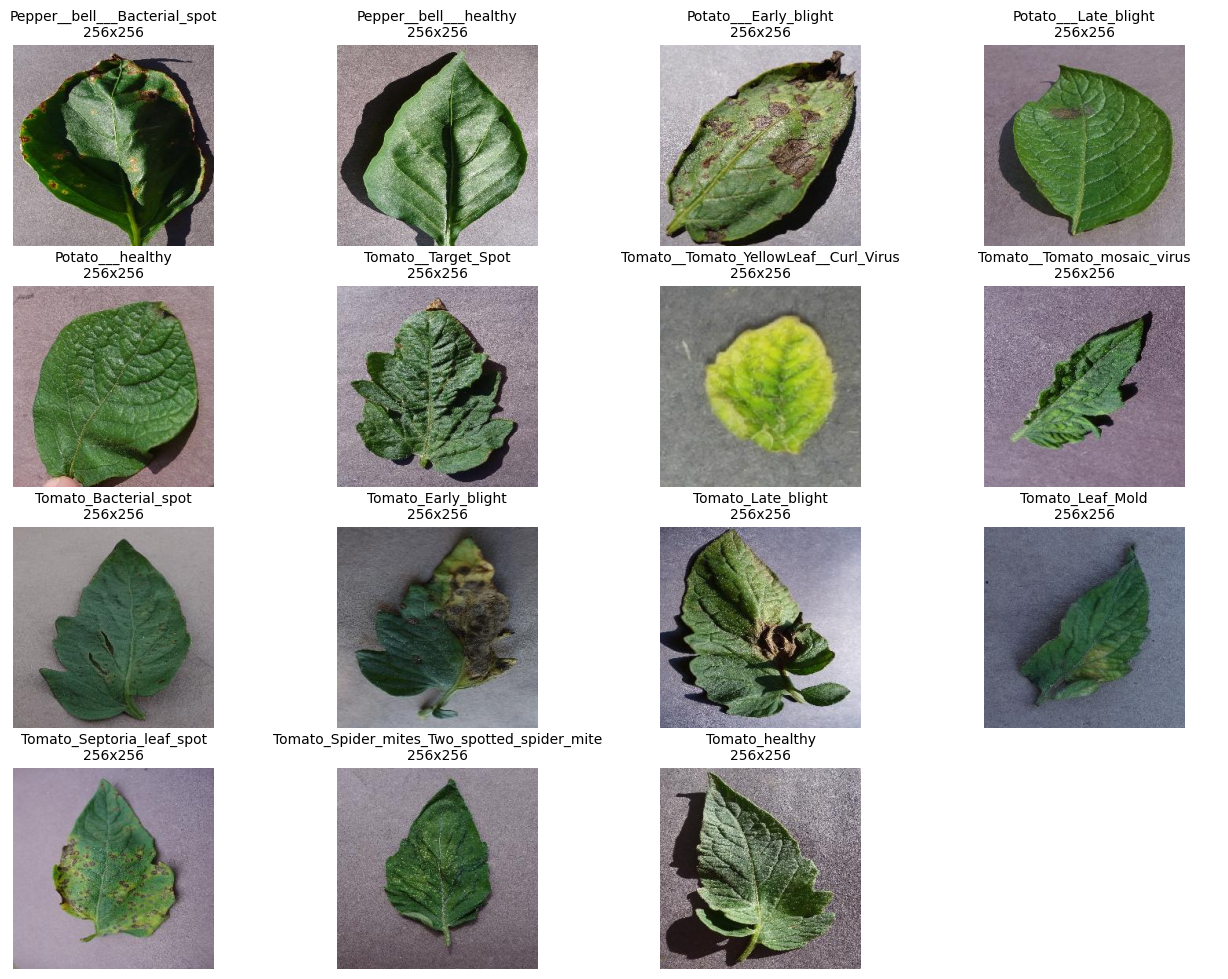

In [ ]:
def VisualizeClasses(folders_path):
    # Get all class folders and sort them
    ClassesNames = os.listdir(folders_path)
    ClassesNames.sort(key=lambda x: (x.split('__')[0], x))

    # Display the total number of classes
    NUM_CLASSES = len(ClassesNames)
    print(f"Classes Number: {NUM_CLASSES}")

    cols = 4
    rows = (NUM_CLASSES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()

    # Show one sample image from each class
    for i, cat in enumerate(ClassesNames):
        ClassFolderPath = os.path.join(folders_path,cat)
        ImagesName = os.listdir(ClassFolderPath)
        img_path = os.path.join(ClassFolderPath,ImagesName[0])
        with Image.open(img_path) as img:
            width, height = img.size
        image = mpimg.imread(img_path)
        axes[i].imshow(image)
        axes[i].set_title(f"{cat}\n{width}x{height}", fontsize=10)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

VisualizeClasses(IMAGES_FOLDERS_PATH)

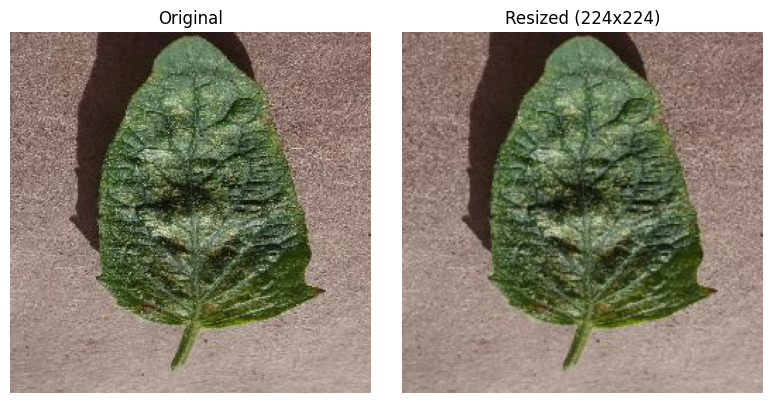

In [ ]:
# Pick a random class folder
ClassesNames = os.listdir(IMAGES_FOLDERS_PATH)
random_class = random.choice(ClassesNames)
class_path = os.path.join(IMAGES_FOLDERS_PATH, random_class)

# Pick a random image from that class
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

# Open and resize the selected image to 224x224
with Image.open(img_path) as img:
    resized_img = img.resize((WIDTH, HEIGHT))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized ({WIDTH}x{HEIGHT})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

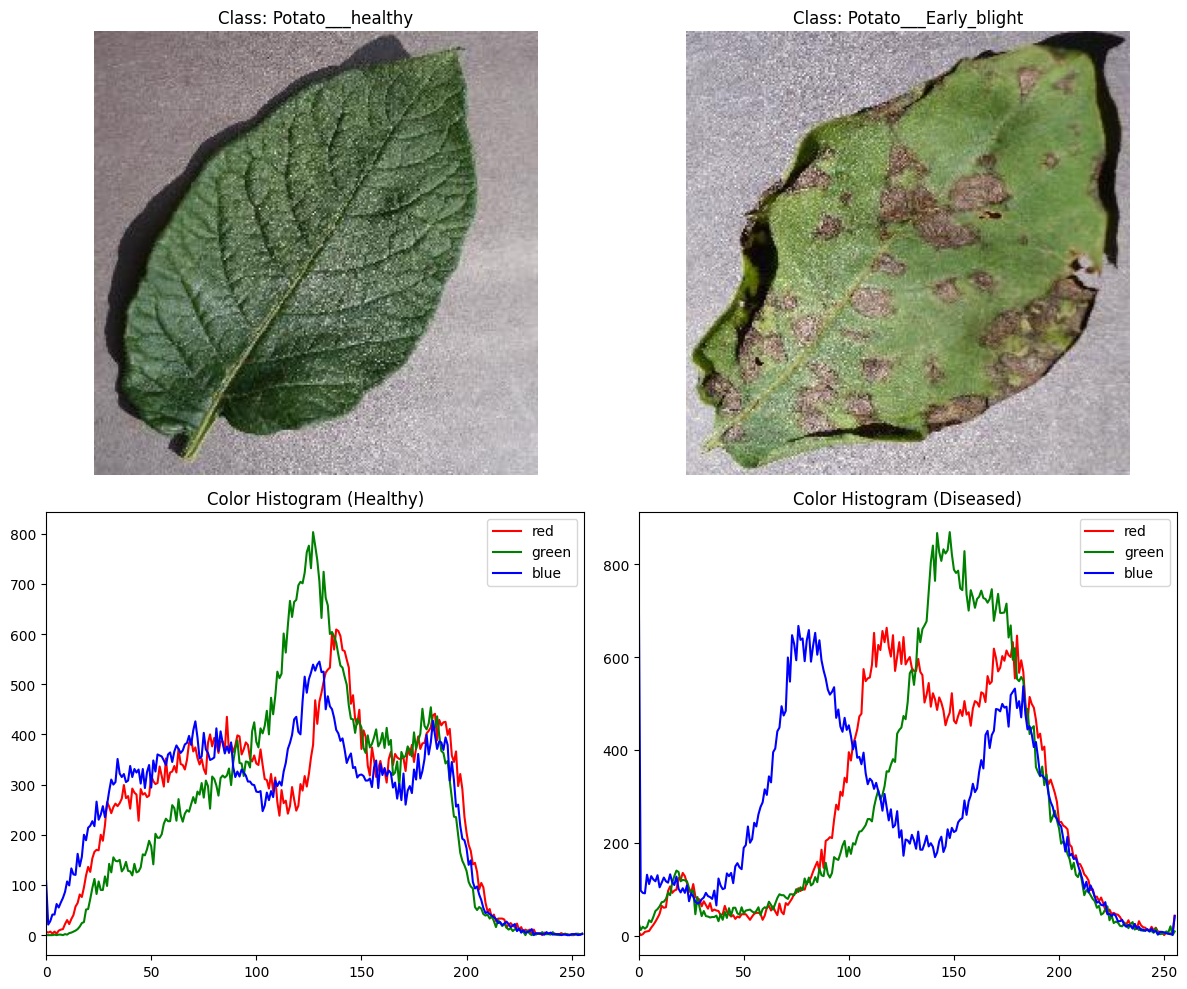

In [ ]:
def plot_healthy_vs_diseased(plant_name):
    all_classes = [d for d in os.listdir(IMAGES_FOLDERS_PATH) if d.startswith(plant_name)]

    healthy_class = [c for c in all_classes if 'healthy' in c.lower()]
    diseased_classes = [c for c in all_classes if 'healthy' not in c.lower()]

    if not healthy_class or not diseased_classes:
        print(f"Couldn't find both healthy and diseased for {plant_name}")
        return

    target_diseased = random.choice(diseased_classes)
    target_healthy = healthy_class[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for i, class_name in enumerate([target_healthy, target_diseased]):
        class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Class: {class_name}")
        axes[0, i].axis('off')

        colors = ('red', 'green', 'blue')
        for j, col in enumerate(colors):
            hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
            axes[1, i].plot(hist, color=col, label=col)
            axes[1, i].set_xlim([0, 256])

        axes[1, i].set_title(f"Color Histogram ({'Healthy' if i==0 else 'Diseased'})")
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

plot_healthy_vs_diseased('Potato')

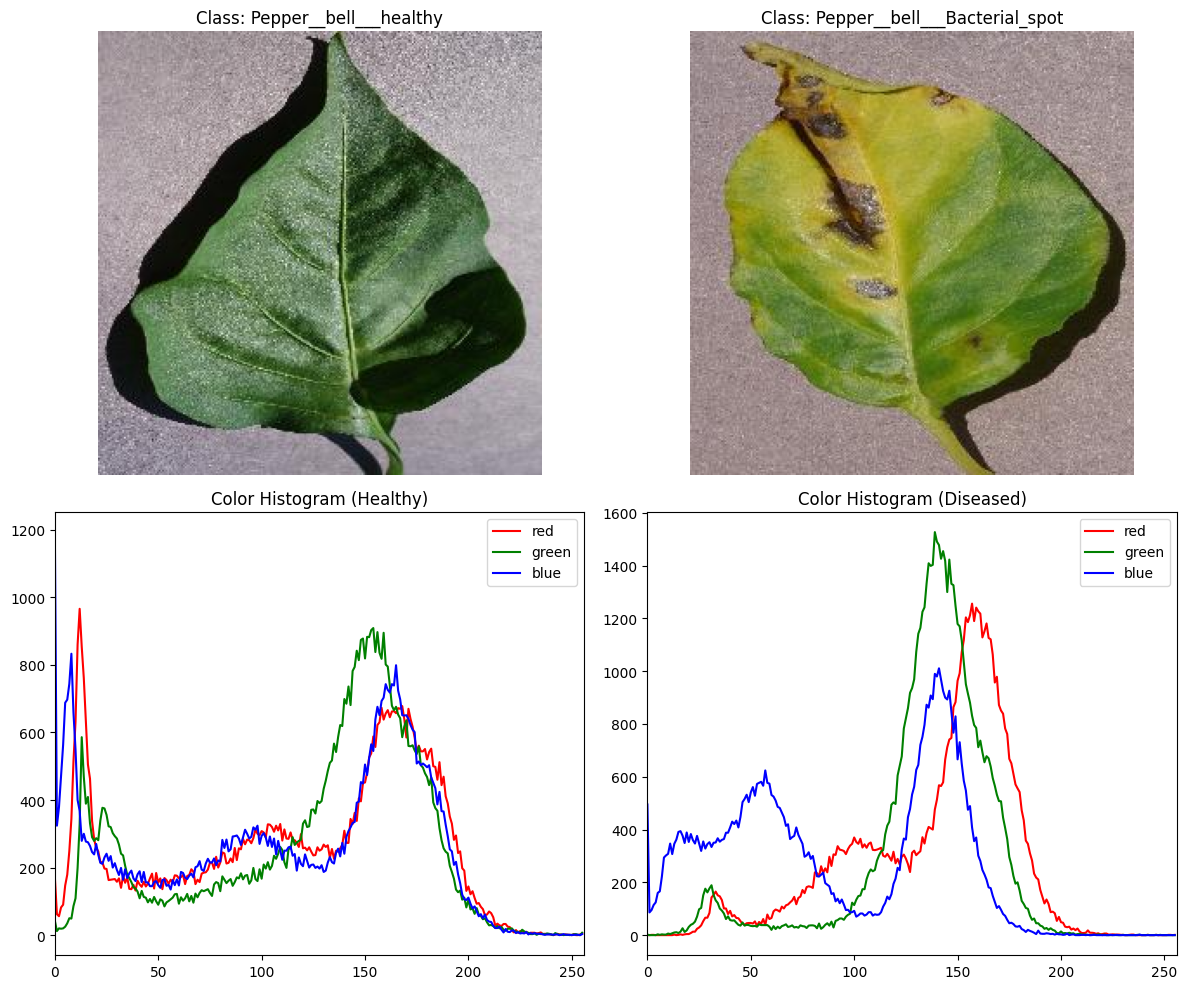

In [ ]:
plot_healthy_vs_diseased('Pepper')

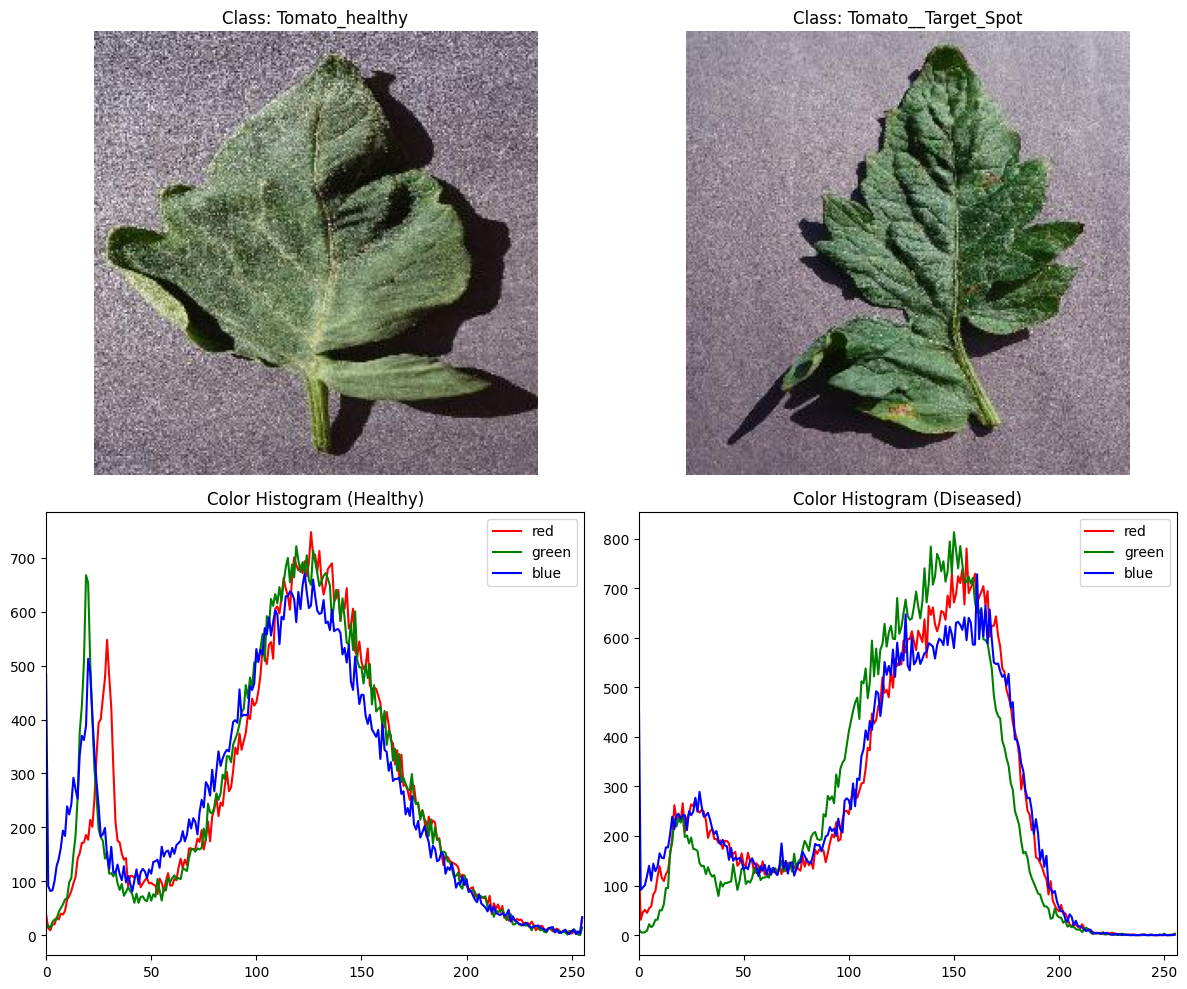

In [ ]:
plot_healthy_vs_diseased('Tomato')

## 5. Data Split (70% train / 15% val / 15% test)

In [8]:
splitfolders.ratio(
    IMAGES_FOLDERS_PATH,
    output=OUTPUT_FOLDER,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

train_path = os.path.join(OUTPUT_FOLDER, "train")
val_path   = os.path.join(OUTPUT_FOLDER, "val")
test_path  = os.path.join(OUTPUT_FOLDER, "test")

print(f"Train : {train_path}")
print(f"Val   : {val_path}")
print(f"Test  : {test_path}")


Copying files: 12 files [02:24, 12.05s/ files]

Copying files: 1 files [00:00,  5.55 files/s]
Copying files: 17 files [00:00, 18.97 files/s]
Copying files: 19 files [00:03,  4.77 files/s]
Copying files: 48 files [00:03, 18.30 files/s]
Copying files: 75 files [00:03, 34.20 files/s]
Copying files: 107 files [00:03, 57.81 files/s]
Copying files: 140 files [00:03, 86.55 files/s]
Copying files: 169 files [00:03, 112.77 files/s]
Copying files: 196 files [00:03, 136.02 files/s]
Copying files: 223 files [00:03, 159.76 files/s]
Copying files: 255 files [00:04, 192.59 files/s]
Copying files: 283 files [00:04, 211.13 files/s]
Copying files: 315 files [00:04, 236.83 files/s]
Copying files: 345 files [00:04, 252.22 files/s]
Copying files: 375 files [00:04, 254.24 files/s]
Copying files: 408 files [00:04, 273.67 files/s]
Copying files: 438 files [00:04, 273.64 files/s]
Copying files: 471 files [00:04, 287.94 files/s]
Copying files: 501 files [00:04, 281.29 files/s]
Copying files: 534 files [00:04, 

Train : plantdisease_split/train
Val   : plantdisease_split/val
Test  : plantdisease_split/test


## 6. Feature Extraction (Color Histogram + LBP + GLCM)

In [ ]:
def compute_color_histogram(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hist_features = []
    for i in range(3):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)
    return hist_features

def compute_texture_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (WIDTH, HEIGHT))

    lbp = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, LBP_METHOD)
    n_bins = LBP_N_POINTS + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                                range=(0, n_bins), density=True)

    gray_small = (gray // 4).astype(np.uint8)
    levels = 64
    glcm   = np.zeros((levels, levels), dtype=np.float64)
    glcm[gray_small[:, :-1].ravel(),
         gray_small[:, 1: ].ravel()] += 1
    glcm += glcm.T
    glcm /= glcm.sum()

    i, j  = np.mgrid[0:levels, 0:levels]
    mu    = (i * glcm).sum()
    denom = np.sqrt((glcm * (i - mu)**2).sum()) * \
            np.sqrt((glcm * (j - mu)**2).sum())

    contrast    = (glcm * (i - j)**2).sum()
    energy      = (glcm**2).sum()
    homogeneity = (glcm / (1.0 + (i - j)**2)).sum()
    correlation = (glcm * (i - mu) * (j - mu)).sum() / (denom + 1e-10)

    return list(lbp_hist) + [contrast, energy, homogeneity, correlation]

In [ ]:
all_images = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        all_images.append((class_name, os.path.join(class_path, img_name)))

print(f"Total images: {len(all_images)}")

Total images: 20639


In [ ]:
data = []

for class_name, img_path in tqdm(all_images, desc="Extracting features"):
    color_features   = compute_color_histogram(img_path)
    texture_features = compute_texture_features(img_path)

    if color_features is None or texture_features is None:
        continue

    final_features = color_features + texture_features
    data.append({'class': class_name, 'features': final_features})

df = pd.DataFrame(data)
df.to_pickle('/kaggle/working/features.pkl')

print(f"Number of Images: {len(df)}")
print(df.head())

Extracting features: 100%|██████████| 20639/20639 [09:43<00:00, 35.36it/s]


Number of Images: 20638
                           class  \
0  Pepper__bell___Bacterial_spot   
1  Pepper__bell___Bacterial_spot   
2  Pepper__bell___Bacterial_spot   
3  Pepper__bell___Bacterial_spot   
4  Pepper__bell___Bacterial_spot   

                                            features  
0  [0.02583752, 0.0077031115, 0.005937815, 0.0083...  
1  [0.006403104, 0.0018294583, 0.0024392777, 0.00...  
2  [0.0007926307, 0.0003170523, 0.00047557845, 0....  
3  [0.00086839765, 0.0007236647, 0.00043419882, 0...  
4  [0.00019173733, 0.0015338986, 0.0007669493, 0....  


In [ ]:
df = pd.read_pickle('/kaggle/working/features.pkl')
X = np.stack(df['features'].values)
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=40, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}\n")

Original number of features: 798
Number of features after PCA: 40



## 7. KNN / Naive Bayes

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
knn_preds = knn.predict(X_test_pca)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")


nb = GaussianNB()
nb.fit(X_train_pca, y_train)
nb_preds = nb.predict(X_test_pca)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds) * 100:.2f}%")

KNN Accuracy: 81.52%
Naive Bayes Accuracy: 53.56%


## 9. CNN (PyTorch)

In [ ]:
TRAIN_DATA_PATH = train_path
VAL_DATA_PATH   = val_path

print (f"Training data path: {TRAIN_DATA_PATH}")
print (f"Validation data path: {VAL_DATA_PATH}")

Training data path: /kaggle/working/plantdisease_split/train
Validation data path: /kaggle/working/plantdisease_split/val


In [ ]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

TRAIN_DATA_TRANSFORMER = transforms.Compose([
    transforms.Resize((WIDTH, HEIGHT)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

TEST_DATA_TRANSFORMER = transforms.Compose([
    transforms.Resize((WIDTH, HEIGHT)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

In [ ]:
train_dataset = ImageFolder(root=TRAIN_DATA_PATH, transform=TRAIN_DATA_TRANSFORMER)
val_dataset = ImageFolder(root=VAL_DATA_PATH, transform=TEST_DATA_TRANSFORMER)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

Number of training samples: 14440
Number of validation samples: 3089


In [ ]:
class_names = train_dataset.classes
print(f"Class names: {class_names}")

Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
class_to_idx = train_dataset.class_to_idx
print(f"Class to index mapping: {class_to_idx}")

Class to index mapping: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count() if os.cpu_count() is not None else 4

TRAIN_DATA_LOADER = DataLoader(
    train_dataset,
    batch_size= BATCH_SIZE,
    shuffle=True,
    num_workers = NUM_WORKERS,
    pin_memory=True
)

TEST_DATA_LOADER = DataLoader(
    val_dataset,
    batch_size= BATCH_SIZE,
    shuffle=False,
    num_workers = NUM_WORKERS,
    pin_memory=True
)

print(f"{len(TRAIN_DATA_LOADER)} Batches in train dataloader")
print(f"{len(TEST_DATA_LOADER)} Batches in test dataloader")

226 Batches in train dataloader
49 Batches in test dataloader


In [ ]:
img,label = next(iter(TRAIN_DATA_LOADER))
img,label

(tensor([[[[-0.2684, -0.1828, -0.1314,  ...,  0.1083,  0.0912,  0.0569],
           [-0.4054, -0.3198, -0.2342,  ..., -0.0458, -0.0116,  0.0398],
           [-0.3883, -0.3541, -0.2856,  ..., -0.0801, -0.0629,  0.0227],
           ...,
           [-0.1314, -0.1143, -0.0801,  ..., -0.2684, -0.2856, -0.3198],
           [-0.1314, -0.0972, -0.0801,  ..., -0.3198, -0.3198, -0.3027],
           [-0.1143, -0.0972, -0.0801,  ..., -0.3712, -0.3541, -0.3198]],
 
          [[-0.2150, -0.1275, -0.0749,  ...,  0.1527,  0.1352,  0.1001],
           [-0.3550, -0.2675, -0.1800,  ..., -0.0049,  0.0301,  0.0826],
           [-0.3375, -0.3025, -0.2325,  ..., -0.0399, -0.0224,  0.0651],
           ...,
           [-0.0049,  0.0126,  0.0476,  ..., -0.1800, -0.1975, -0.2325],
           [-0.0049,  0.0301,  0.0476,  ..., -0.2325, -0.2325, -0.2150],
           [ 0.0126,  0.0301,  0.0476,  ..., -0.2850, -0.2675, -0.2325]],
 
          [[ 0.0256,  0.1128,  0.1651,  ...,  0.4439,  0.4265,  0.3916],
           [-

In [ ]:
img.shape

torch.Size([64, 3, 224, 224])

In [ ]:
# Implement the CNN model
class VGG_CNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()

        # Block 1: Input (3, 224, 224) -> Output (32, 112, 112)
        self.cnn_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: Input (32, 112, 112) -> Output (64, 56, 56)
        self.cnn_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: Input (64, 56, 56) -> Output (128, 28, 28)
        self.cnn_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 4: Input (128, 28, 28) -> Output (256, 14, 14)
        self.cnn_block_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.neural_network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(14 * 14 * 256, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.cnn_block_1(x)
        x = self.cnn_block_2(x)
        x = self.cnn_block_3(x)
        x = self.cnn_block_4(x)
        x = self.neural_network(x)
        return x

base_model = VGG_CNN()

In [ ]:
summary(base_model,input_size=[1,3,224,224])

Layer (type:depth-idx)                   Output Shape              Param #
VGG_CNN                                  [1, 15]                   --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 64, 112, 112]         18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         128
│    └─ReLU: 2-7                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-8                    [1, 64, 56, 56]           --
├─Sequential: 1-3                        [1, 128, 28, 28]          --
│    └─Conv2d: 2-9                       [1, 128, 56, 56]          73,856
│    

In [ ]:
loss_fn = nn.CrossEntropyLoss()
acc_fn = Accuracy(task="multiclass", num_classes=len(class_names)).to(device)
optimizer = torch.optim.Adam(params=base_model.parameters(),lr=0.001,weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer,
                              mode='min',
                              factor=0.1,
                              patience=3,
                              )

In [ ]:
# Create train & test step functions
def train_step(
    model: nn.Module,
    dataloader: torch.utils.data,
    loss_fn: nn.Module,
    acc_fn,
    optimizer: torch.optim,
    device=device
):
  model.train()
  total_loss, total_acc = 0,0
  for batch,(X,y) in enumerate(dataloader):
    X = X.to(device)
    y = y.to(device)
    y_logits = model(X)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
    loss = loss_fn(y_logits,y)
    acc = acc_fn(y_pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    total_acc += acc.item()
  total_loss /= len(dataloader)
  total_acc /= len(dataloader)
  return total_loss,total_acc


def test_step(
    model: nn.Module,
    dataloader: torch.utils.data,
    loss_fn: nn.Module,
    acc_fn,
    device=device
):
  model.eval()
  total_loss, total_acc = 0,0
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X = X.to(device)
      y = y.to(device)
      y_logits = model(X)
      y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
      total_loss += loss_fn(y_logits,y).item()
      total_acc += acc_fn(y_pred,y).item()
    total_loss /= len(dataloader)
    total_acc /= len(dataloader)
  return total_loss,total_acc

In [ ]:
# Create main train loop for epochs
SAVE_FROM_SCRATCH_MODEL_PATH = f"/kaggle/working/model_from_scratch.pth"
def train(model: nn.Module,
          train_dataloader: torch.utils.data,
          test_dataloader: torch.utils .data,
          loss_fn: nn.Module,
          acc_fn,
          optimizer: torch.optim,
          epochs: int,
          patience: int = 5,
          seed=42,
          ):
  torch.random.manual_seed(seed)
  results = {
      'Train Loss': [],
      'Train Accuracy': [],
      'Test Loss': [],
      'Test Accuracy': []
  }
  best_loss = float('inf')
  patience_counter = 0
  for epoch in tqdm_auto(range(epochs)):
    train_loss,train_acc = train_step(model,train_dataloader,loss_fn,acc_fn,optimizer)
    test_loss,test_acc = test_step(model,test_dataloader,loss_fn,acc_fn)
    scheduler.step(test_loss)
    if test_loss < best_loss:
        best_loss = test_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_FROM_SCRATCH_MODEL_PATH)
    else:
        patience_counter += 1
    print(f"Epoch {epoch+1}/{epochs} - accuracy: {train_acc*100:.2f}% - loss: {train_loss:.4f} - val_accuracy: {test_acc*100:.2f}% - val_loss: {test_loss:.4f}")
    results["Train Loss"].append(train_loss),results["Train Accuracy"].append(train_acc),results["Test Loss"].append(test_loss),results["Test Accuracy"].append(test_acc)
    if patience_counter >= patience:
            print(f"--- Early stopping triggered at epoch {epoch+1} ---")
            break
  model.load_state_dict(torch.load(SAVE_FROM_SCRATCH_MODEL_PATH, weights_only=True))
  return results

In [ ]:
base_model = base_model.to(device)
base_model_results = train(base_model,TRAIN_DATA_LOADER,TEST_DATA_LOADER,loss_fn,acc_fn,optimizer,30)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30 - accuracy: 42.32% - loss: 2.9582 - val_accuracy: 65.77% - val_loss: 1.1571
Epoch 2/30 - accuracy: 62.83% - loss: 1.1632 - val_accuracy: 81.03% - val_loss: 0.5781
Epoch 3/30 - accuracy: 70.38% - loss: 0.9230 - val_accuracy: 79.82% - val_loss: 0.5912
Epoch 4/30 - accuracy: 75.01% - loss: 0.7622 - val_accuracy: 80.29% - val_loss: 0.5822
Epoch 5/30 - accuracy: 77.85% - loss: 0.6691 - val_accuracy: 90.08% - val_loss: 0.3064
Epoch 6/30 - accuracy: 79.92% - loss: 0.6125 - val_accuracy: 87.44% - val_loss: 0.3823
Epoch 7/30 - accuracy: 81.32% - loss: 0.5661 - val_accuracy: 89.23% - val_loss: 0.3123
Epoch 8/30 - accuracy: 82.47% - loss: 0.5240 - val_accuracy: 89.99% - val_loss: 0.2790
Epoch 9/30 - accuracy: 83.53% - loss: 0.5011 - val_accuracy: 90.69% - val_loss: 0.2660
Epoch 10/30 - accuracy: 84.02% - loss: 0.4802 - val_accuracy: 90.25% - val_loss: 0.2846
Epoch 11/30 - accuracy: 84.33% - loss: 0.4803 - val_accuracy: 90.40% - val_loss: 0.2985
Epoch 12/30 - accuracy: 85.74% - loss: 0.

In [ ]:
def get_predections(model: nn.Module, dataloader: torch.utils.data, device=device):
  model_prediction = []
  model.eval()
  with torch.inference_mode():
    for batch,(X,y) in tqdm_auto(enumerate(dataloader)):
      X = X.to(device)
      y = y.to(device)
      y_logits = model(X)
      y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)
      model_prediction.append(y_preds)
  return torch.cat(model_prediction)

model0_predictions = get_predections(base_model,TEST_DATA_LOADER)
model0_predictions

0it [00:00, ?it/s]

tensor([ 0,  0,  0,  ..., 14, 14, 14], device='cuda:0')

In [ ]:
base_model_results_table = pd.DataFrame(base_model_results)
base_model_results_table

,Train Loss,Train Accuracy,Test Loss,Test Accuracy
0,2.958152,0.423189,1.157073,0.657676
1,1.163151,0.628291,0.578116,0.810343
2,0.923018,0.703816,0.591194,0.798151
3,0.762178,0.750083,0.582227,0.802934
4,0.669073,0.778526,0.306398,0.900829
5,0.612468,0.799198,0.382326,0.874437
6,0.566124,0.813164,0.312348,0.892294
7,0.524034,0.824737,0.279007,0.899947
8,0.501096,0.835301,0.265995,0.906888
9,0.480214,0.840169,0.284558,0.902498


## 8. Bagging Algorithms

In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
acc_rf = accuracy_score(y_test,y_pred_rf)
print(f"RandomForest Accuracy: { acc_rf*100:.2f}%")

RandomForest Accuracy: 85.27%


In [ ]:
base_classifier = DecisionTreeClassifier()
#bagging
bagging_classifier = BaggingClassifier(base_classifier ,n_estimators=10,random_state=42)
bagging_classifier.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

In [ ]:
y_pred = bagging_classifier.predict(X_test)
acc_bagging = accuracy_score(y_test,y_pred)
print(f"Bagging Accuracy:{acc_bagging *100:.2f}%")

Bagging Accuracy:78.78%


## Boosting algorthim(adaboost)

In [ ]:
ada = AdaBoostClassifier( estimator=base_classifier,n_estimators=300,learning_rate=0.1 , random_state=42)
ada.fit(X_train ,y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test , y_pred_ada)
print(f"AdaBoost Accuracy: {acc_ada*100:.2f}%")

AdaBoost Accuracy: 65.43%


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_params = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1,2]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=cv, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_pca, y_train_enc)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best KNN CV Accuracy:", knn_grid.best_score_)

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best KNN CV Accuracy: 0.8321623258631133


In [ ]:
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'criterion': ['entropy']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced',oob_score=True),
    rf_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_pca, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF CV Accuracy:", rf_grid.best_score_)

Best RF Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV Accuracy: 0.8373107207752877


In [ ]:
bagging_params = {
    'n_estimators': [50, 100],
    'max_samples': [0.8, 1.0],
    'max_features': [0.8, 1.0]
}

bagging_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'), random_state=42),
    bagging_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

bagging_grid.fit(X_train_pca, y_train)

print(f"Best Bagging Params: {bagging_grid.best_params_}")
print(f"Best Bagging CV Accuracy: {bagging_grid.best_score_:.4f}")

Best Bagging Params: {'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 100}
Best Bagging CV Accuracy: 0.8264


In [ ]:
ada_params = {
    'n_estimators': [50, 150],
    'learning_rate': [0.1, 0.5]
}

base_est = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_est, random_state=42),
    ada_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

ada_grid.fit(X_train_pca, y_train)

print(f"Best AdaBoost Params: {ada_grid.best_params_}")
print(f"Best AdaBoost CV Accuracy: {ada_grid.best_score_:.4f}")

Best AdaBoost Params: {'learning_rate': 0.5, 'n_estimators': 150}
Best AdaBoost CV Accuracy: 0.7455


In [ ]:
results = {
    'Model': ['KNN', 'Random Forest', 'Bagging', 'AdaBoost'],
    'Best CV Accuracy': [
        knn_grid.best_score_,
        rf_grid.best_score_,
        bagging_grid.best_score_,
        ada_grid.best_score_
    ]
}
df_results = pd.DataFrame(results).sort_values(by='Best CV Accuracy', ascending=False)

print("--- 1. Models Comparison (Validation Phase) ---")
print(df_results)
print("\n" + "="*50 + "\n")


final_model = rf_grid.best_estimator_
y_pred = final_model.predict(X_test_pca)

print("--- 2. Final Evaluation (Best Model: Random Forest) ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- 1. Models Comparison (Validation Phase) ---
           Model  Best CV Accuracy
1  Random Forest          0.837311
0            KNN          0.832162
2        Bagging          0.826408
3       AdaBoost          0.745548


--- 2. Final Evaluation (Best Model: Random Forest) ---
Final Test Accuracy: 0.8341

Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.81      0.77      0.79       199
                     Pepper__bell___healthy       0.81      0.83      0.82       296
                      Potato___Early_blight       0.87      0.93      0.90       200
                       Potato___Late_blight       0.78      0.71      0.74       200
                           Potato___healthy       0.85      0.57      0.68        30
                      Tomato_Bacterial_spot       0.84      0.89      0.86       426
                        Tomato_Early_blight       0.79      0.

## 10. AutoEncoders

### load data

In [ ]:
autoencoder_data = IMAGES_FOLDERS_PATH
#filter healthy images from dataset
healthy_data = []
#resize the images
img_size = 128

print("Starting to load healthy images...")
for folder in os.listdir(autoencoder_data):
    if 'healthy' in folder.lower():
        folder_path = os.path.join(autoencoder_data, folder)

        for img_name in os.listdir(folder_path):
            try:
                img_path = os.path.join(folder_path, img_name)
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (img_size, img_size))

                healthy_data.append(image)
            except Exception as e:
                pass

print(f"Done! Loaded {len(healthy_data)} healthy images.")

Starting to load healthy images...
Done! Loaded 3221 healthy images.


### Data engineering

In [ ]:
healthy_data = np.array(healthy_data, dtype='float32')
#Normalization
healthy_data = healthy_data / 255.0
print(f"Data shape: {healthy_data.shape}")
#split
x_train, x_val = train_test_split(healthy_data, test_size=0.2, random_state=42)
print(f"Training set: {x_train.shape}")
print(f"Validation set: {x_val.shape}")

Data shape: (3221, 128, 128, 3)
Training set: (2576, 128, 128, 3)
Validation set: (645, 128, 128, 3)


### Model Archeticture

In [ ]:
input_shape = (128, 128, 3)
autoencoder_model = models.Sequential([
    #encoder
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    #Decoder
    layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same'),

    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])
#autoencoder
autoencoder_model.compile(optimizer='adam', loss='mse')
autoencoder_model.summary()

I0000 00:00:1777119926.740372      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10199 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777119926.745596      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 32)   │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,939 (54.45 KB)

 Trainable params: 13,939 (54.45 KB)

 Non-trainable params: 0 (0.00 B)

### Training phase

In [ ]:
epochsNum = 50
batchSize = 32

history = autoencoder_model.fit(x_train, x_train,epochs=epochsNum,batch_size=batchSize,
    validation_data=(x_val, x_val),  shuffle=True
)

Epoch 1/50


I0000 00:00:1777119932.381647    1378 service.cc:152] XLA service 0x782ca800bf40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777119932.381699    1378 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777119932.381706    1378 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777119932.877811    1378 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 12:25:34.923559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:25:35.196123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:25:35.699581: E external/local_xl

 5/81 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0315

I0000 00:00:1777119938.002558    1378 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0293

2026-04-25 12:25:41.577819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:25:41.714891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0291 - val_loss: 0.0172
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0168 - val_loss: 0.0142
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0139 - val_loss: 0.0121
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0109 - val_loss: 0.0085
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0082 - val_loss: 0.0076
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0074 - val_loss: 0.0075
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0070 - val_loss: 0.0068
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0065 - val_loss: 0.0063
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0057 - val_loss: 0.0060
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0058 - val_

### Output

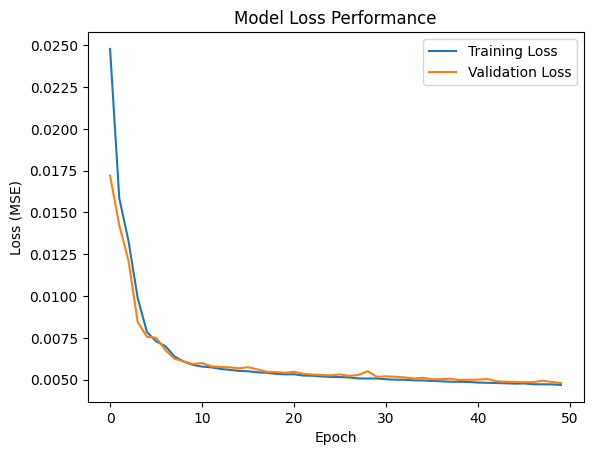

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Performance')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 11. Transfer Learning — MobileNetV2 & EfficientNetB0

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)
class_names_tf = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32
)

Found 14440 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.


In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

In [ ]:
base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_mobilenet.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_mobilenet = tf.keras.Sequential([
    base_mobilenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names_tf), activation='softmax')
])

In [ ]:
model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


2026-04-25 12:28:19.367326: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:28:19.504482: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


451/452 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6298 - loss: 1.2019

2026-04-25 12:28:43.247813: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:28:43.405481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:28:43.540940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6301 - loss: 1.2010

2026-04-25 12:29:01.458322: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:29:01.594679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


452/452 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.6303 - loss: 1.2002 - val_accuracy: 0.8744 - val_loss: 0.3921
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8576 - loss: 0.4296 - val_accuracy: 0.8909 - val_loss: 0.3188
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8828 - loss: 0.3489 - val_accuracy: 0.8886 - val_loss: 0.3174
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9011 - loss: 0.2990 - val_accuracy: 0.9071 - val_loss: 0.2685
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9080 - loss: 0.2618 - val_accuracy: 0.9074 - val_loss: 0.2587
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9247 - loss: 0.2258 - val_accuracy: 0.9003 - val_loss: 0.2762
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9304 - loss: 0.1956 - val_accuracy: 0.9119 - val_loss: 0.2561
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9391 - loss: 0.1749 - val_accurac

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNetB0 has built-in preprocessing.
# train_ds is already normalized to [0,1] via Rescaling(1./255) above,
# so we just prefetch — no second division.
train_ds_e = train_ds.prefetch(AUTOTUNE)
val_ds_e   = val_ds.prefetch(AUTOTUNE)
test_ds_e  = test_ds.prefetch(AUTOTUNE)


In [ ]:
base_efficientnet = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_efficientnet.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_efficientnet = tf.keras.Sequential([
    base_efficientnet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names_tf), activation='softmax')
])

In [ ]:
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_efficientnet = model_efficientnet.fit(
    train_ds_e,
    validation_data=val_ds_e,
    epochs=10
)

Epoch 1/10


2026-04-25 12:31:41.695257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:31:41.838644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:31:42.195184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:31:42.335988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:31:43.141002: E external/local_xla/xla/stream_

450/452 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1386 - loss: 2.6166

2026-04-25 12:32:11.191333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:11.327861: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:11.639870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:11.781460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:12.604596: E external/local_xla/xla/stream_

452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1386 - loss: 2.6165

2026-04-25 12:32:32.455843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:32.597113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:32.923035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:33.064406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:32:33.858293: E external/local_xla/xla/stream_

452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 105ms/step - accuracy: 0.1387 - loss: 2.6165 - val_accuracy: 0.1557 - val_loss: 2.5735
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.1491 - loss: 2.5911 - val_accuracy: 0.1557 - val_loss: 2.5717
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1491 - loss: 2.5845 - val_accuracy: 0.1557 - val_loss: 2.5701
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1513 - loss: 2.5836 - val_accuracy: 0.1557 - val_loss: 2.5694
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1551 - loss: 2.5800 - val_accuracy: 0.1557 - val_loss: 2.5678
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1533 - loss: 2.5825 - val_accuracy: 0.1557 - val_loss: 2.5672
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1554 - loss: 2.5766 - val_accuracy: 0.1557 - val_loss: 2.5661
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1540 - loss: 2.5803 - val_accura

In [ ]:
mobilenet_acc    = model_mobilenet.evaluate(test_ds,   verbose=0)[1]
efficientnet_acc = model_efficientnet.evaluate(test_ds_e, verbose=0)[1]

print("MobileNet Accuracy:", mobilenet_acc)
print("EfficientNet Accuracy:", efficientnet_acc)


2026-04-25 12:35:47.319956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:35:47.474640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:35:47.610315: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:35:56.543060: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 12:35:56.678708: E external/local_xla/xla/stream_

MobileNet Accuracy: 0.9327757954597473
EfficientNet Accuracy: 0.15503376722335815


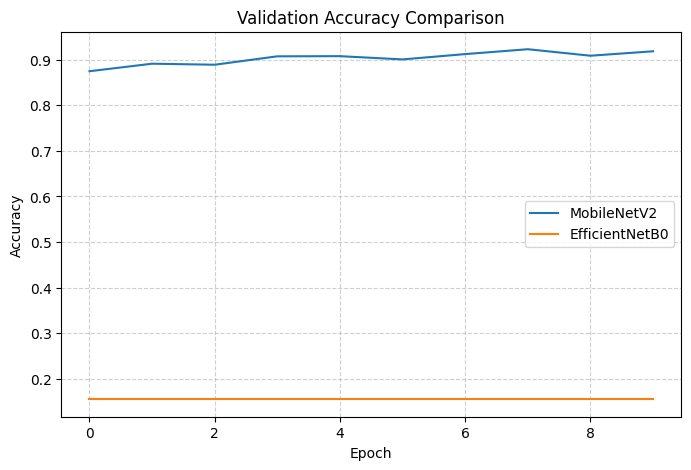

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history['val_accuracy'],    label='MobileNetV2')
plt.plot(history_efficientnet.history['val_accuracy'], label='EfficientNetB0')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## 12. Optimizer Comparison (Adam / SGD / RMSprop)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")

In [ ]:
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [ ]:
def build_model(optimizer, name):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(len(class_names_tf), activation='softmax')
    ], name=name)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

# ── Adam ──────────────────────────────────────────────────────────────
print("-- Adam --")
# Rebuild augmentation + pipeline after each clear_session()
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

model = build_model(tf.keras.optimizers.Adam(1e-4), "Adam")
history_adam = model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=5, callbacks=[early_stop], verbose=1
)
adam_acc = model.evaluate(test_ds, verbose=0)[1]
del model
tf.keras.backend.clear_session()


# ── SGD ───────────────────────────────────────────────────────────────
print("\n-- SGD --")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

model = build_model(tf.keras.optimizers.SGD(0.01, momentum=0.9), "SGD")
history_sgd = model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=5, callbacks=[early_stop], verbose=1
)
sgd_acc = model.evaluate(test_ds, verbose=0)[1]
del model
tf.keras.backend.clear_session()


# ── RMSprop ───────────────────────────────────────────────────────────
print("\n-- RMSprop --")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

model = build_model(tf.keras.optimizers.RMSprop(1e-4), "RMSprop")
history_rms = model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=5, callbacks=[early_stop], verbose=1
)
rms_acc = model.evaluate(test_ds, verbose=0)[1]
del model
tf.keras.backend.clear_session()


print("\nFinal Results:")
print(f"Adam    : {adam_acc:.4f}")
print(f"SGD     : {sgd_acc:.4f}")
print(f"RMSprop : {rms_acc:.4f}")

best = max(
    {"Adam": adam_acc, "SGD": sgd_acc, "RMSprop": rms_acc},
    key=lambda x: {"Adam": adam_acc, "SGD": sgd_acc, "RMSprop": rms_acc}[x]
)
print(f"\nBest Optimizer: {best}")


-- Adam --
Epoch 1/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 92s 182ms/step - accuracy: 0.3186 - loss: 2.3917 - val_accuracy: 0.7167 - val_loss: 0.9261
Epoch 2/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 155ms/step - accuracy: 0.6724 - loss: 1.0254 - val_accuracy: 0.7744 - val_loss: 0.6963
Epoch 3/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.7312 - loss: 0.8269 - val_accuracy: 0.8025 - val_loss: 0.6077
Epoch 4/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.7666 - loss: 0.7067 - val_accuracy: 0.8216 - val_loss: 0.5457
Epoch 5/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 156ms/step - accuracy: 0.7985 - loss: 0.6133 - val_accuracy: 0.8339 - val_loss: 0.5097

-- SGD --
Epoch 1/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 91s 180ms/step - accuracy: 0.6307 - loss: 1.2424 - val_accuracy: 0.8174 - val_loss: 0.5416
Epoch 2/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 153ms/step - accuracy: 0.7977 - loss: 0.6224 - val_accuracy: 0.8537 - val_loss: 0.4183
Epoch 3/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 156ms/step - accuracy: 0.

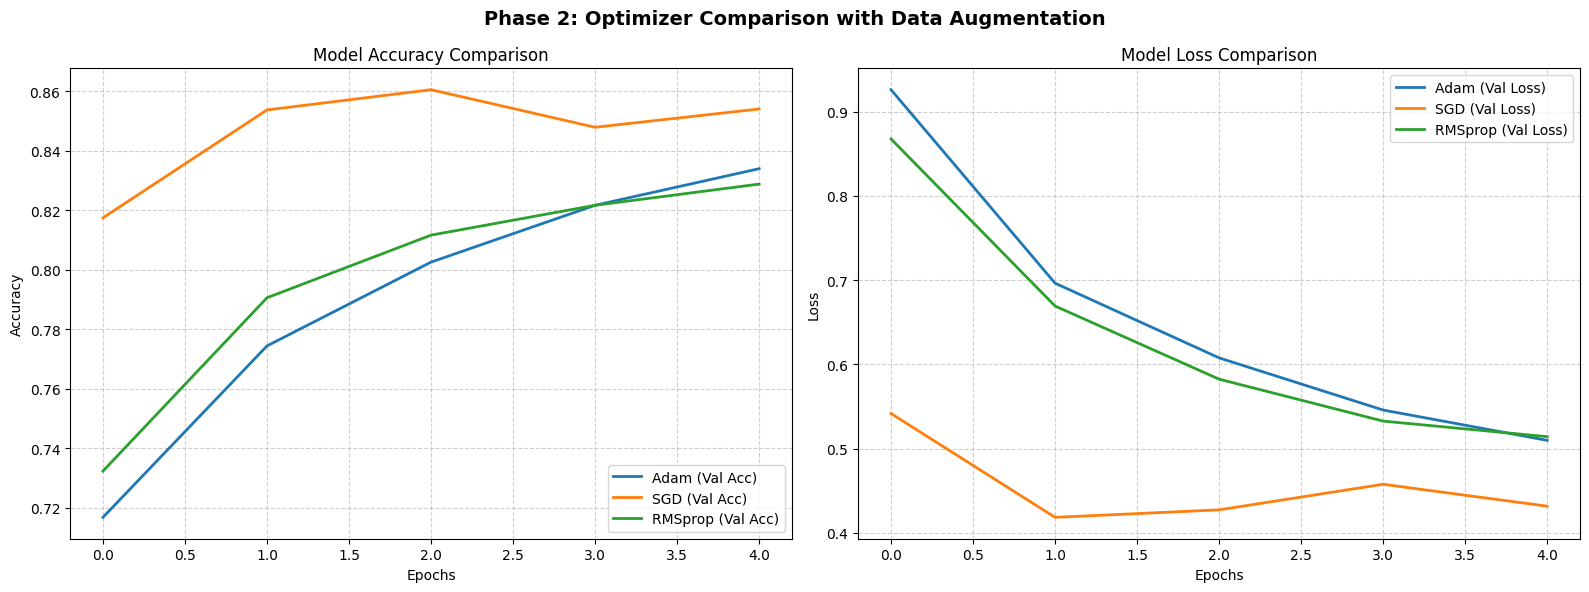

In [ ]:
histories = {
    "Adam": history_adam,
    "SGD": history_sgd,
    "RMSprop": history_rms
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Phase 2: Optimizer Comparison with Data Augmentation", fontsize=14, fontweight='bold')

for name, hist in histories.items():
    ax1.plot(hist.history['val_accuracy'], label=f'{name} (Val Acc)', linewidth=2)
    ax2.plot(hist.history['val_loss'], label=f'{name} (Val Loss)', linewidth=2)

ax1.set_title("Model Accuracy Comparison")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.set_title("Model Loss Comparison")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("/kaggle/working/optimizer_performance_curves.png", dpi=150)
plt.show()

In [ ]:
print("\n" + "="*40)
print(" SUMMARY: TEST ACCURACY")
print("="*40)
print(f"Adam    : {adam_acc:.4f}")
print(f"SGD     : {sgd_acc:.4f}")
print(f"RMSprop : {rms_acc:.4f}")
print("-" * 40)
print(f"WINNING OPTIMIZER: {best}")
print("="*40)


 SUMMARY: TEST ACCURACY
Adam    : 0.8450
SGD     : 0.8742
RMSprop : 0.8475
----------------------------------------
WINNING OPTIMIZER: SGD


## 13.Confusion Matrix Dashboard

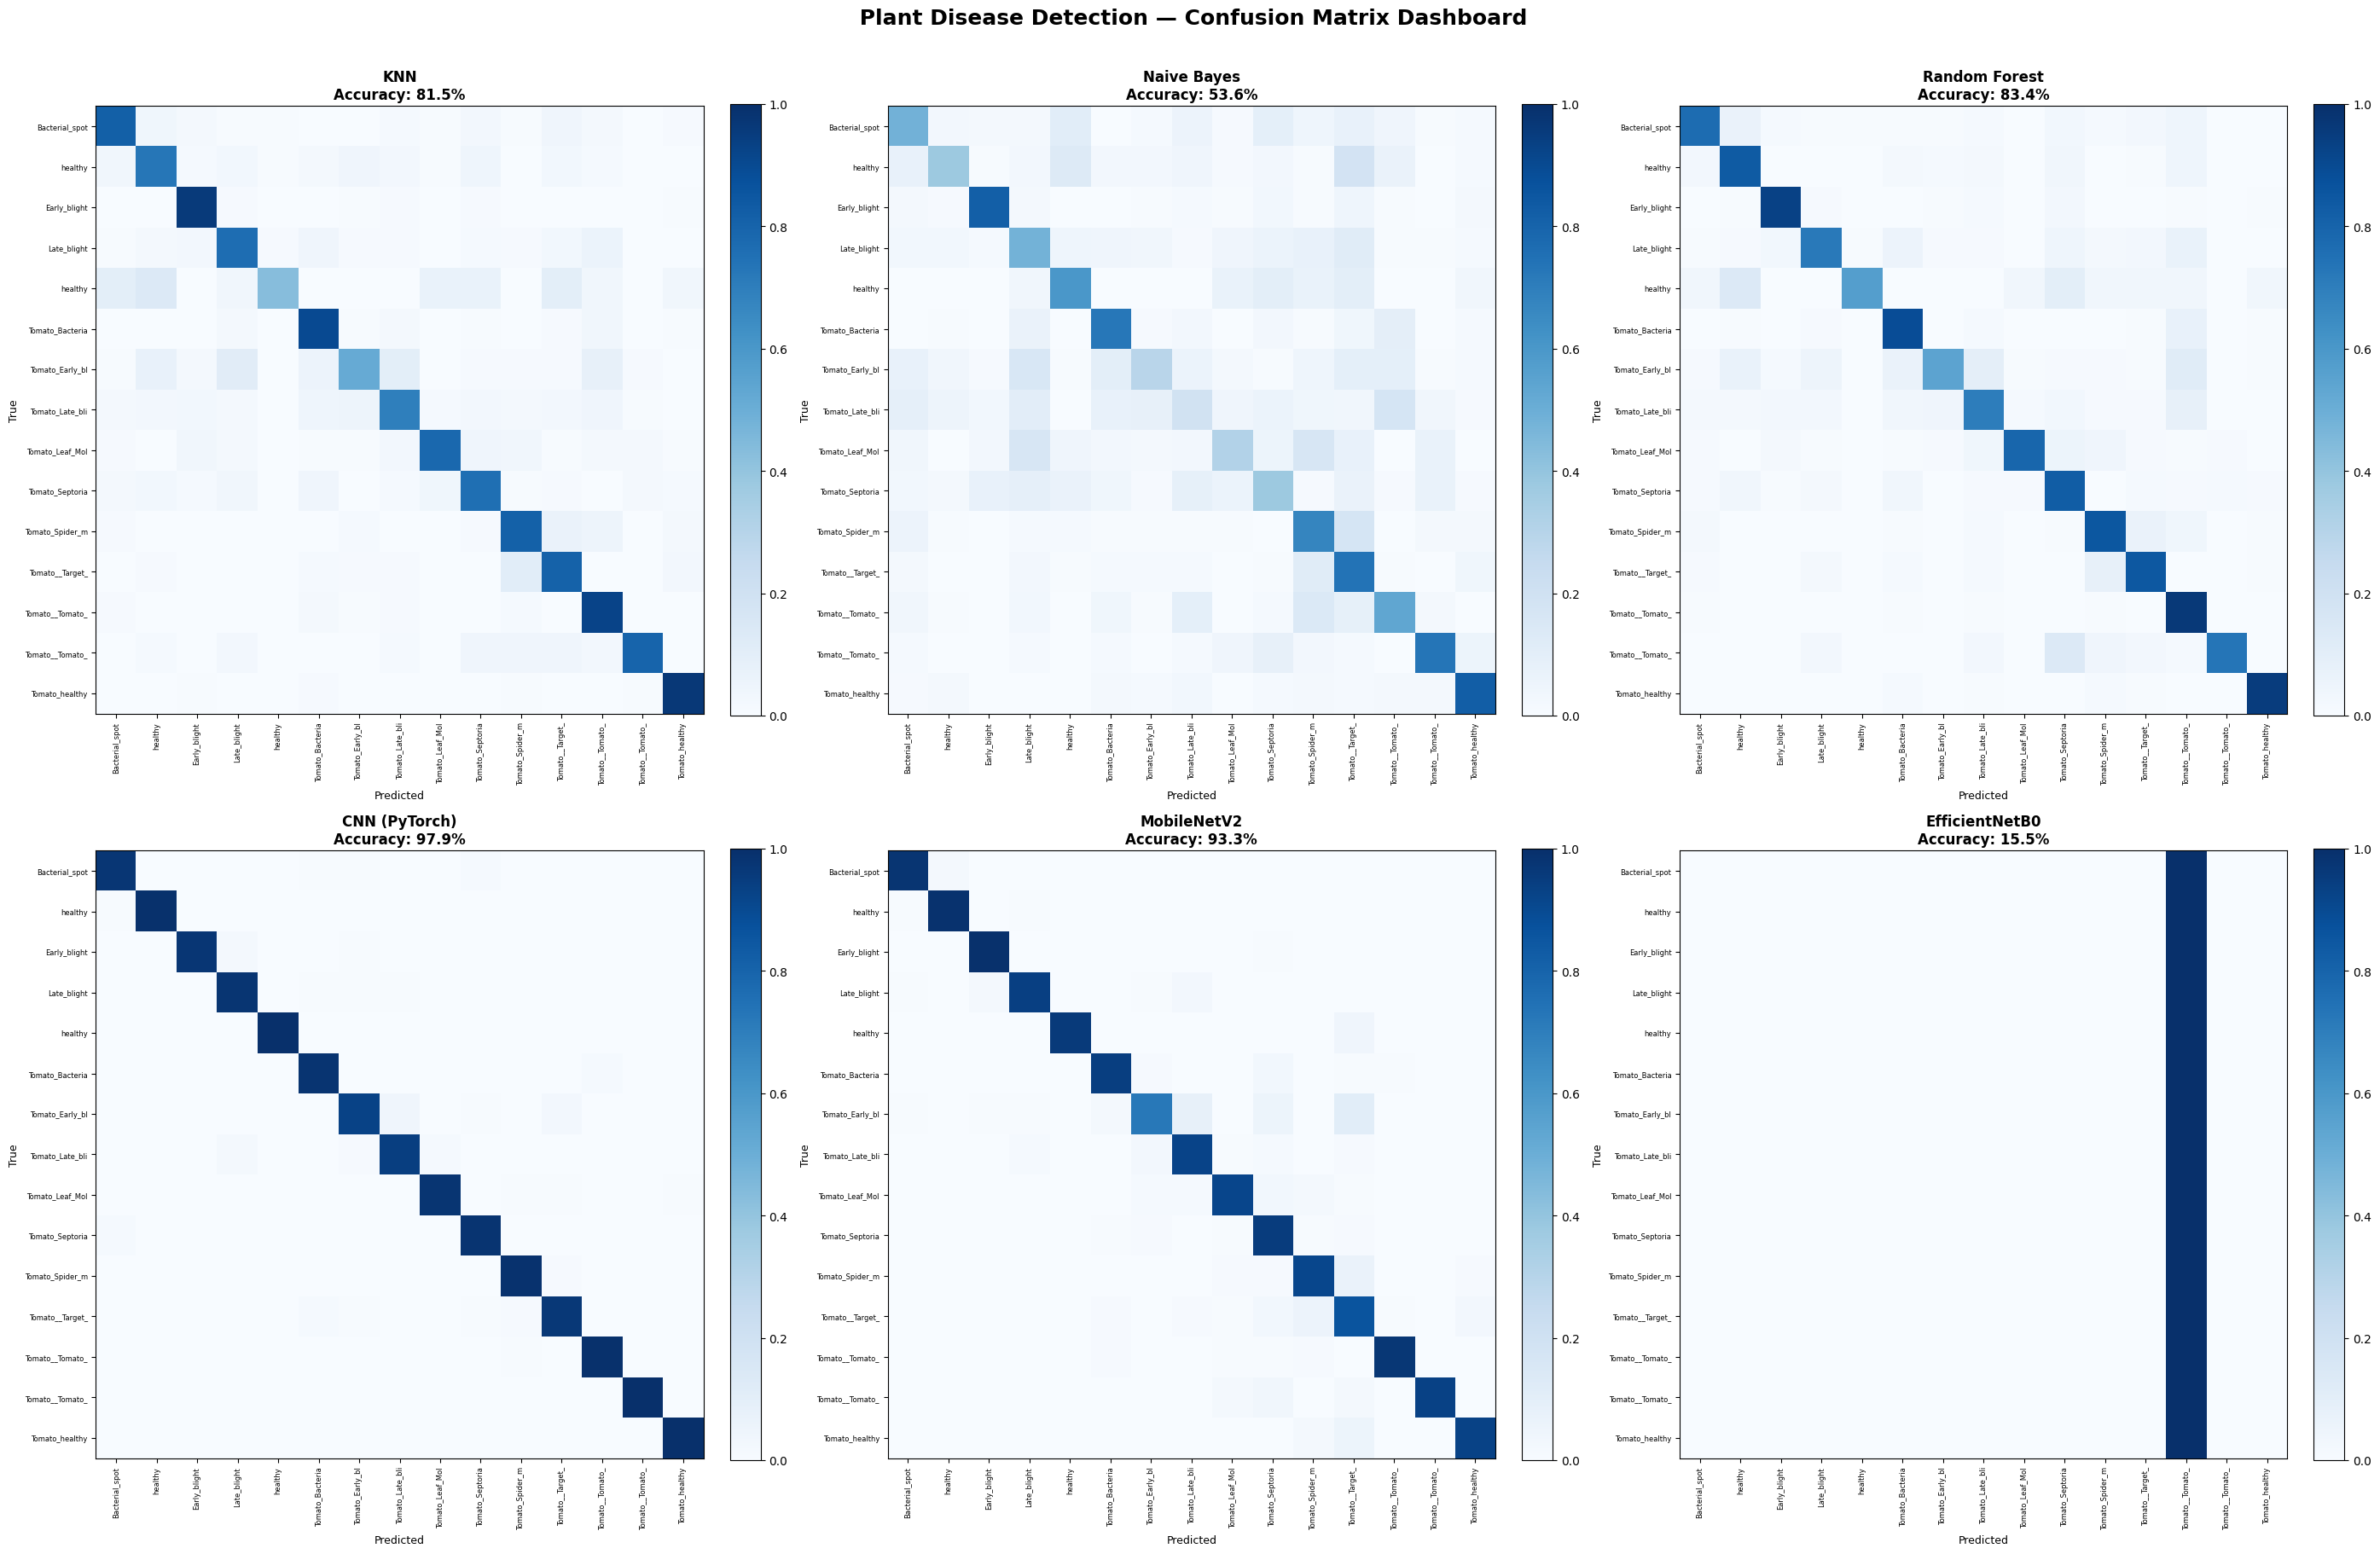

 Saved: /kaggle/working/confusion_matrix_dashboard.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║           CONFUSION MATRIX DASHBOARD                        ║
# ╚══════════════════════════════════════════════════════════════╝

# KNN
knn_cm_preds = knn.predict(X_test_pca)

# Naive Bayes
nb_cm_preds = nb.predict(X_test_pca)

# Random Forest (best from GridSearch)
rf_cm_preds = rf_grid.best_estimator_.predict(X_test_pca)


cnn_true_labels = []
for _, labels in TEST_DATA_LOADER:
    cnn_true_labels.extend(labels.numpy())
cnn_true_labels = np.array(cnn_true_labels)
cnn_preds = model0_predictions.cpu().numpy()

# MobileNetV2
mobilenet_preds_list, mobilenet_true_list = [], []
for x_batch, y_batch in test_ds:
    preds = model_mobilenet.predict(x_batch, verbose=0)
    mobilenet_preds_list.extend(np.argmax(preds, axis=1))
    mobilenet_true_list.extend(y_batch.numpy())
mobilenet_preds = np.array(mobilenet_preds_list)
mobilenet_true  = np.array(mobilenet_true_list)

# EfficientNetB0
efficientnet_preds_list, efficientnet_true_list = [], []
for x_batch, y_batch in test_ds_e:
    preds = model_efficientnet.predict(x_batch, verbose=0)
    efficientnet_preds_list.extend(np.argmax(preds, axis=1))
    efficientnet_true_list.extend(y_batch.numpy())
efficientnet_preds = np.array(efficientnet_preds_list)
efficientnet_true  = np.array(efficientnet_true_list)


models_info = [
    ("KNN",          y_test,          knn_cm_preds,        class_names),
    ("Naive Bayes",  y_test,          nb_cm_preds,         class_names),
    ("Random Forest",y_test,          rf_cm_preds,         class_names),
    ("CNN (PyTorch)",cnn_true_labels, cnn_preds,           class_names),
    ("MobileNetV2",  mobilenet_true,  mobilenet_preds,     class_names_tf),
    ("EfficientNetB0",efficientnet_true, efficientnet_preds, class_names_tf),
]

fig, axes = plt.subplots(2, 3, figsize=(28, 18))
fig.suptitle(" Plant Disease Detection — Confusion Matrix Dashboard",
             fontsize=18, fontweight='bold', y=1.01)

for ax, (name, y_true, y_pred, labels) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_true, y_pred)

    # normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # short label names (remove long prefix)
    short_labels = [l.split('___')[-1][:15] if '___' in l else l[:15] for l in labels]

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(short_labels, fontsize=6)

    # accuracy on title
    acc = np.diag(cm).sum() / cm.sum()
    ax.set_title(f"{name}\nAccuracy: {acc*100:.1f}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: /kaggle/working/confusion_matrix_dashboard.png")

---
## Phase 3 — RNN Model

> **Goal:** Classify plant diseases using a pure (vanilla) RNN built with TensorFlow/Keras.  
> Because RNNs are designed for sequential data, each image is treated as a sequence of rows (time-steps), where each row's pixel values form the feature vector at that step.  
> Architecture: **Image rows → SimpleRNN layers → Dense classifier**
---

### 3.1 — Imports & Setup

In [6]:
# ── Phase 3: Extra imports (TF/Keras already available from Phase 1/2) ──
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility seed
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 3.2 Data Preprocessing for RNN Input

**Strategy — row as timestep encoding:**  
- Images are resized to `(IMG_H, IMG_W, 3)` = `(64, 64, 3)`.  
- Each image becomes a sequence of **64 timesteps** (one per pixel row).  
- Each timestep has **64 × 3 = 192 features** (RGB values of that row).  
- Pixel values are normalised to `[0, 1]`.

In [9]:
# RNN-specific hyper-parameters
RNN_IMG_H  = 64
RNN_IMG_W  = 64
RNN_BATCH  = 32
RNN_EPOCHS = 30

print('Train path :', train_path)
print('Val   path :', val_path)
print('Test  path :', test_path)

Train path : plantdisease_split/train
Val   path : plantdisease_split/val
Test  path : plantdisease_split/test


In [10]:
# Build tf.data pipelines
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_for_rnn(image, label):

    image = tf.image.resize(image, [RNN_IMG_H, RNN_IMG_W])
    image = tf.cast(image, tf.float32) / 255.0
    # Treat each pixel-row as one RNN timestep
    image = tf.reshape(image, [RNN_IMG_H, RNN_IMG_W * 3])  # (64, 192)
    return image, label

# Load raw datasets
rnn_train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(RNN_IMG_H, RNN_IMG_W),
    batch_size=None,          # unbatched so we can apply per-sample ops cleanly
    label_mode='int',
    shuffle=True,
    seed=42
)

rnn_val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(RNN_IMG_H, RNN_IMG_W),
    batch_size=None,
    label_mode='int',
    shuffle=False
)

rnn_test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(RNN_IMG_H, RNN_IMG_W),
    batch_size=None,
    label_mode='int',
    shuffle=False
)

# Capture class names from the training dataset
rnn_class_names = rnn_train_ds_raw.class_names
NUM_CLASSES_RNN  = len(rnn_class_names)
print(f'Number of classes: {NUM_CLASSES_RNN}')
print('Sample class names:', rnn_class_names[:5])

Found 14440 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.
Number of classes: 15
Sample class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [11]:
#Apply preprocessing + batch + prefetch
rnn_train_ds = (
    rnn_train_ds_raw
    .map(preprocess_for_rnn, num_parallel_calls=AUTOTUNE)
    .batch(RNN_BATCH)
    .prefetch(AUTOTUNE)
)

rnn_val_ds = (
    rnn_val_ds_raw
    .map(preprocess_for_rnn, num_parallel_calls=AUTOTUNE)
    .batch(RNN_BATCH)
    .prefetch(AUTOTUNE)
)

rnn_test_ds = (
    rnn_test_ds_raw
    .map(preprocess_for_rnn, num_parallel_calls=AUTOTUNE)
    .batch(RNN_BATCH)
    .prefetch(AUTOTUNE)
)

# Sanity-check the shape: should be (batch, 64, 192)
for x_sample, y_sample in rnn_train_ds.take(1):
    print('Input batch shape :', x_sample.shape)   # (32, 64, 192)
    print('Label batch shape :', y_sample.shape)   # (32,)

Input batch shape : (32, 64, 192)
Label batch shape : (32,)


### 3.3 RNN Model Architecture

**Design choices:**
- Two stacked `SimpleRNN` layers — the first returns sequences so the second can process them.
- `Dropout` after each RNN layer to regularise and reduce overfitting.
- A final `Dense` classifier with `softmax` for multi-class output.

In [12]:
# Build the pure RNN model
def build_rnn_model(timesteps, features_per_step, num_classes):
    model = models.Sequential(name='PlantDisease_RNN', layers=[

        layers.Input(shape=(timesteps, features_per_step),
                     name='sequence_input'),

        # RNN Block 1
        # return_sequences=True passes the full sequence to the next RNN layer
        layers.SimpleRNN(
            units=128,
            activation='tanh',
            return_sequences=True,  # feed into next RNN layer
            name='rnn_block_1'
        ),
        layers.Dropout(0.3, name='dropout_1'),

        # RNN Block 2
        # return_sequences=False → only the final hidden state is passed forward
        layers.SimpleRNN(
            units=64,
            activation='tanh',
            return_sequences=False,
            name='rnn_block_2'
        ),
        layers.Dropout(0.3, name='dropout_2'),

        #  Dense Classifier
        layers.Dense(128, activation='relu', name='dense_hidden'),
        layers.Dropout(0.4, name='dropout_3'),
        layers.Dense(num_classes, activation='softmax', name='output'),
    ])
    return model

# Instantiate
rnn_model = build_rnn_model(
    timesteps=RNN_IMG_H,
    features_per_step=RNN_IMG_W * 3,
    num_classes=NUM_CLASSES_RNN
)

rnn_model.summary()

Model: "PlantDisease_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_block_1 (SimpleRNN)         │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_block_2 (SimpleRNN)         │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,695 (248.81 KB)

 Trainable params: 63,695 (248.81 KB)

 Non-trainable params: 0 (0.00 B)

### 3.4 Compile the Model

In [13]:
#Compile with Adam + sparse categorical cross-entropy
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


### 3.5 — Training Callbacks

In [14]:
#Callbacks

# EarlyStopping
early_stop_rnn = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau — lower learning rate when val_loss plateaus
reduce_lr_rnn = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# save the best weights during training
checkpoint_rnn = callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/rnn_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print('Callbacks ready.')

Callbacks ready.


### 3.6 Training

In [15]:
# Train the RNN
print('Starting RNN training...')
print(f'  Epochs     : {RNN_EPOCHS}')
print(f'  Batch size : {RNN_BATCH}')
print(f'  Input shape: (batch, {RNN_IMG_H}, {RNN_IMG_W * 3})')
print('─' * 50)

rnn_history = rnn_model.fit(
    rnn_train_ds,
    validation_data=rnn_val_ds,
    epochs=RNN_EPOCHS,
    callbacks=[early_stop_rnn, reduce_lr_rnn, checkpoint_rnn],
    verbose=1
)

print('Training complete.')

Starting RNN training...
  Epochs     : 30
  Batch size : 32
  Input shape: (batch, 64, 192)
──────────────────────────────────────────────────
Epoch 1/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1230 - loss: 2.6767
Epoch 1: val_accuracy improved from None to 0.16089, saving model to /content/drive/MyDrive/rnn_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/rnn_best_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.1353 - loss: 2.6223 - val_accuracy: 0.1609 - val_loss: 2.5571 - learning_rate: 0.0010
Epoch 2/30
450/452 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1558 - loss: 2.5372
Epoch 2: val_accuracy improved from 0.16089 to 0.17676, saving model to /content/drive/MyDrive/rnn_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/rnn_best_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.1578 - loss: 2.5329 - val_accuracy: 0.1768 - val_loss: 2.4955 - learning_rate: 0.0010
Epoch 3/3

### 3.7 Training & Validation Curves

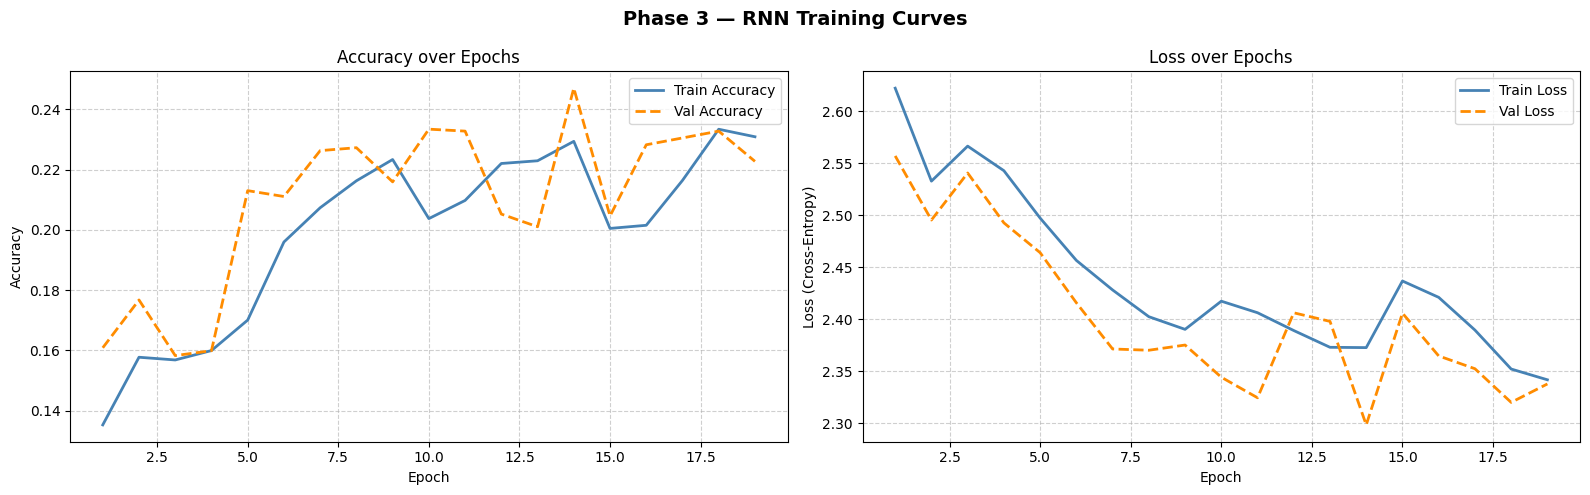

Saved: /content/drive/MyDrive/rnn_training_curves.png


In [16]:
#  Plot accuracy and loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 3 — RNN Training Curves', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(rnn_history.history['accuracy']) + 1)

#  Accuracy
ax1.plot(epochs_ran, rnn_history.history['accuracy'],
         label='Train Accuracy', linewidth=2, color='steelblue')
ax1.plot(epochs_ran, rnn_history.history['val_accuracy'],
         label='Val Accuracy', linewidth=2, color='darkorange', linestyle='--')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# ── Loss
ax2.plot(epochs_ran, rnn_history.history['loss'],
         label='Train Loss', linewidth=2, color='steelblue')
ax2.plot(epochs_ran, rnn_history.history['val_loss'],
         label='Val Loss', linewidth=2, color='darkorange', linestyle='--')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Cross-Entropy)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rnn_training_curves.png', dpi=150)
plt.show()
print('Saved: /content/drive/MyDrive/rnn_training_curves.png')

### 3.8 — Evaluation on Test Set

In [17]:
# Evaluate on the held-out test split
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(rnn_test_ds, verbose=1)

print('─' * 40)
print(f'RNN Test Loss     : {rnn_test_loss:.4f}')
print(f'RNN Test Accuracy : {rnn_test_acc * 100:.2f}%')
print('─' * 40)

98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2576 - loss: 2.2666
────────────────────────────────────────
RNN Test Loss     : 2.2666
RNN Test Accuracy : 25.76%
────────────────────────────────────────


### 3.9 — Generate Predictions for Metrics

In [18]:
# Collect true labels and predicted labels from the test set
rnn_y_true = []
rnn_y_pred = []

for x_batch, y_batch in rnn_test_ds:
    preds      = rnn_model.predict(x_batch, verbose=0)   # (batch, num_classes)
    pred_classes = np.argmax(preds, axis=1)               # class indices
    rnn_y_true.extend(y_batch.numpy())
    rnn_y_pred.extend(pred_classes)

rnn_y_true = np.array(rnn_y_true)
rnn_y_pred = np.array(rnn_y_pred)

print(f'Total test samples : {len(rnn_y_true)}')
print(f'Overall accuracy   : {accuracy_score(rnn_y_true, rnn_y_pred) * 100:.2f}%')

Total test samples : 3109
Overall accuracy   : 25.76%


### 3.10 — Classification Report

In [19]:
# Per-class precision, recall, F1-score
print('Classification Report — Phase 3 RNN Model')
print('=' * 60)
print(
    classification_report(
        rnn_y_true,
        rnn_y_pred,
        target_names=rnn_class_names,
        digits=4
    )
)

Classification Report — Phase 3 RNN Model
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.0000    0.0000    0.0000       151
                     Pepper__bell___healthy     0.2977    0.5740    0.3920       223
                      Potato___Early_blight     0.0000    0.0000    0.0000       150
                       Potato___Late_blight     0.0000    0.0000    0.0000       150
                           Potato___healthy     0.0000    0.0000    0.0000        24
                      Tomato_Bacterial_spot     0.1644    0.4125    0.2351       320
                        Tomato_Early_blight     0.0000    0.0000    0.0000       150
                         Tomato_Late_blight     0.4750    0.1986    0.2801       287
                           Tomato_Leaf_Mold     0.0000    0.0000    0.0000       144
                  Tomato_Septoria_leaf_spot     0.0000    0.0000    0.0000       267
Tomato_Spider_mites_Tw